In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import plot_binned_median_map, _nice_step, _grid_step, bin_edges_fd, binned_median


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.227996,-0.449990,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.231212,-0.339872,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.393163,-0.229470,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,1.184753,-0.030921,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,0.948719,-0.199901,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,0.877251,-0.200469,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,0.867521,-0.100735,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [4]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,large1,split,split2,merge,merge2,shapes2,interaction,interaction2,area,deta
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003


In [5]:
df_AE = df_ameda[df_ameda.Cyc=='AE'].copy()
df_CE = df_ameda[df_ameda.Cyc=='CE'].copy()
print(f'No. of AEs {len(df_AE.Eddy.unique())}, No. of AE-Days {len(df_AE)}')
print(f'No. of CEs {len(df_CE.Eddy.unique())}, No. of CE-Days {len(df_CE)}')
print(f'Oldest AE was {df_AE.Age.max()} days old')
print(f'Oldest CE was {df_CE.Age.max()} days old')


No. of AEs 2142, No. of AE-Days 76861
No. of CEs 1377, No. of CE-Days 27709
Oldest AE was 602 days old
Oldest CE was 113 days old


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


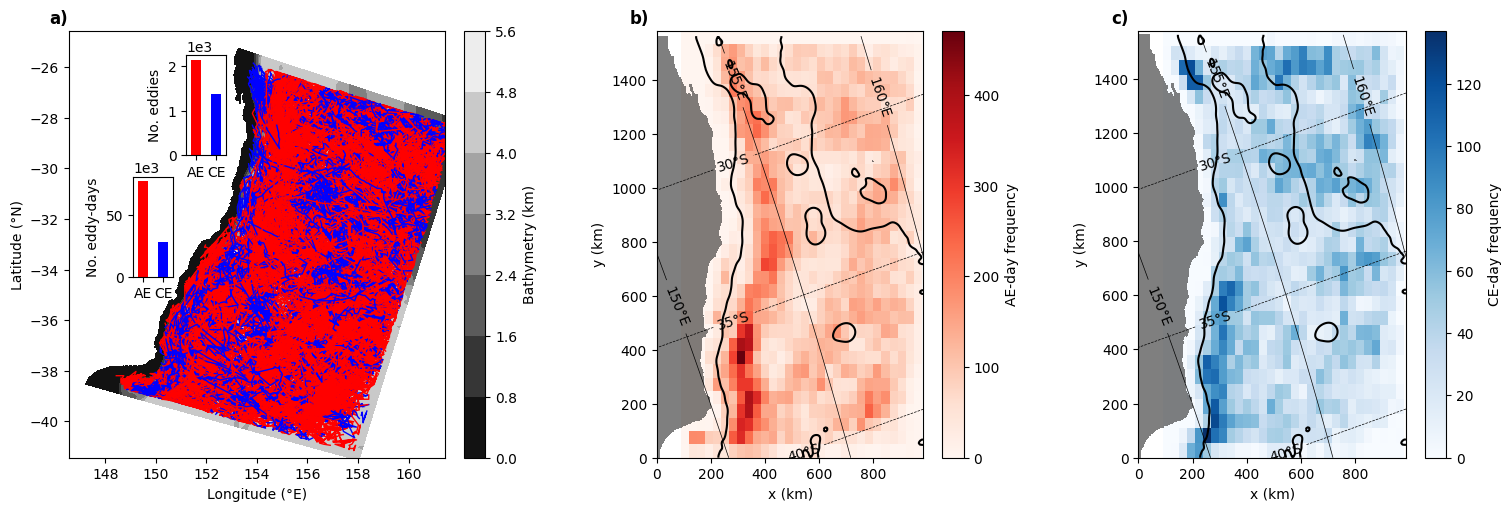

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# --- Panel 1: Map with eddy tracks and insets ---
ax = axs[0]
cs = ax.contourf(lon_rho, lat_rho, np.where(mask_rho, h/1000, np.nan), cmap='grey')
fig.colorbar(cs, ax=ax, label='Bathymetry (km)')

for eddy in df_ameda.Eddy.unique():
    d = df_ameda[df_ameda.Eddy == eddy]
    # ax.plot(d.Lon, d.Lat, lw=1, alpha=1)
    cyc = d.iloc[0].Cyc
    ax.plot(d.lon, d.lat, color='r' if cyc=='AE' else 'b', lw=1, alpha=1)

ax.axis('equal')
ax.set_xlim(148, 160)
ax.set_ylim(-40, -26)
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')

# Inset 1: Eddy counts
df_unique = df_ameda[['Eddy', 'Cyc']].drop_duplicates()
in_ax1 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(152, -27.5, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_unique['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax1)
in_ax1.set_xlabel('')
in_ax1.set_ylabel('No. eddies')
in_ax1.tick_params(axis='x', rotation=0)
in_ax1.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax1.set_facecolor('none')

# Inset 2: Eddy-day counts
in_ax2 = inset_axes(ax, width=.4, height=1, loc='center',
                   bbox_to_anchor=(149.9, -32.3, 0, 0),
                   bbox_transform=ax.transData, borderpad=0)
counts = df_ameda['Cyc'].value_counts().reindex(['AE','CE']).fillna(0)
counts.plot(kind='bar', color=['r','b'], ax=in_ax2)
in_ax2.set_xlabel('')
in_ax2.set_ylabel('No. eddy-days')
in_ax2.tick_params(axis='x', rotation=0)
in_ax2.ticklabel_format(axis='y', style='sci', scilimits=(3, 3))
in_ax2.set_facecolor('none')

# --- Panel 2 & 3: Eddy-day distributions ---
for d, subset in enumerate([df_ameda[df_ameda.Cyc == 'AE'], df_ameda[df_ameda.Cyc == 'CE']]):
    eddy_x = subset.xc.to_numpy()
    eddy_y = subset.yc.to_numpy()

    x_edges = bin_edges_fd(eddy_x, X_grid, rule='fd')  # or rule='scott'/'fd'
    y_edges = bin_edges_fd(eddy_y, Y_grid, rule='fd')

    H, _, _ = np.histogram2d(eddy_y, eddy_x, bins=[y_edges, x_edges])

    pcm = axs[d+1].pcolormesh(x_edges, y_edges, H, cmap='Reds' if d==0 else 'Blues')
    fig.colorbar(pcm, ax=axs[d+1], label='AE-day frequency' if d==0 else 'CE-day frequency')

    axs[d+1].contourf(X_grid, Y_grid, np.where(mask_rho == 0, 1, np.nan),
                      levels=[0.5, 1.5], colors=['k'], alpha=.5)

    c1 = axs[d+1].contour(X_grid, Y_grid, lat_rho, levels=[-40, -35, -30, -25], colors='k', linewidths=.5)
    axs[d+1].clabel(c1, fmt=lambda v: f"{np.abs(v):.0f}°S", inline=True, colors='k')
    c2 = axs[d+1].contour(X_grid, Y_grid, lon_rho, levels=[150, 155, 160], colors='k', linewidths=.5)
    axs[d+1].clabel(c2, fmt=lambda v: f"{v:.0f}°E", inline=True, colors='k')

    axs[d+1].set_xlabel('x (km)')
    axs[d+1].set_ylabel('y (km)')
    axs[d+1].set_aspect('equal')
    axs[d+1].contour(X_grid, Y_grid, h, levels=[4000], colors='k')

axs[0].text(-0.05, 1.05, 'a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].text(-0.1, 1.05, 'b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].text(-0.1, 1.05, 'c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
# plt.tight_layout()
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


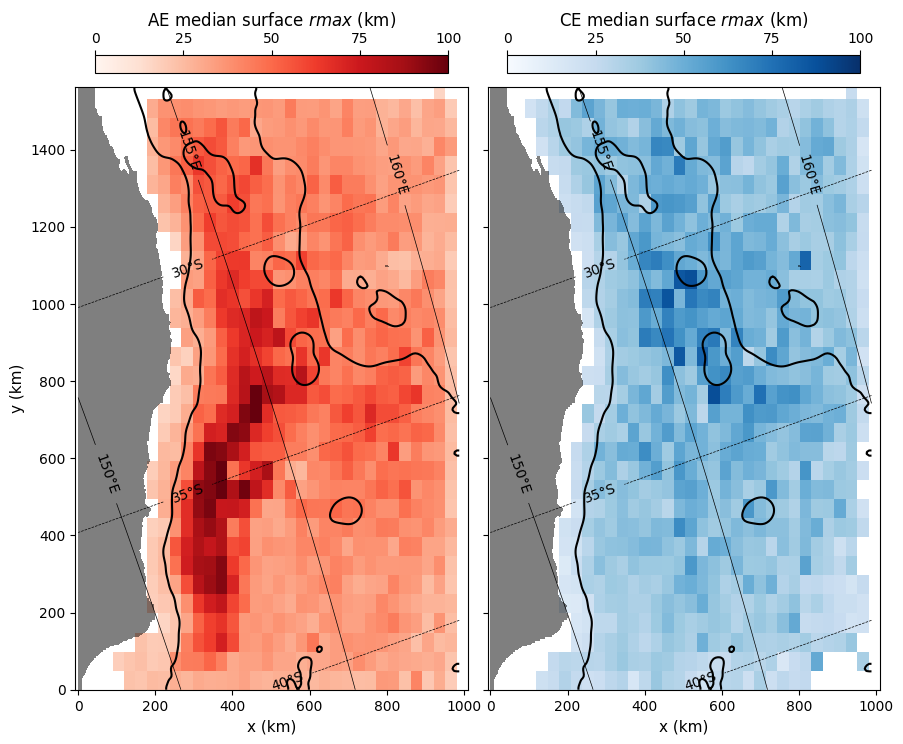

In [7]:
fig, axs = plot_binned_median_map(df_ameda, metric='rmax', vmin=0, vmax=100)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


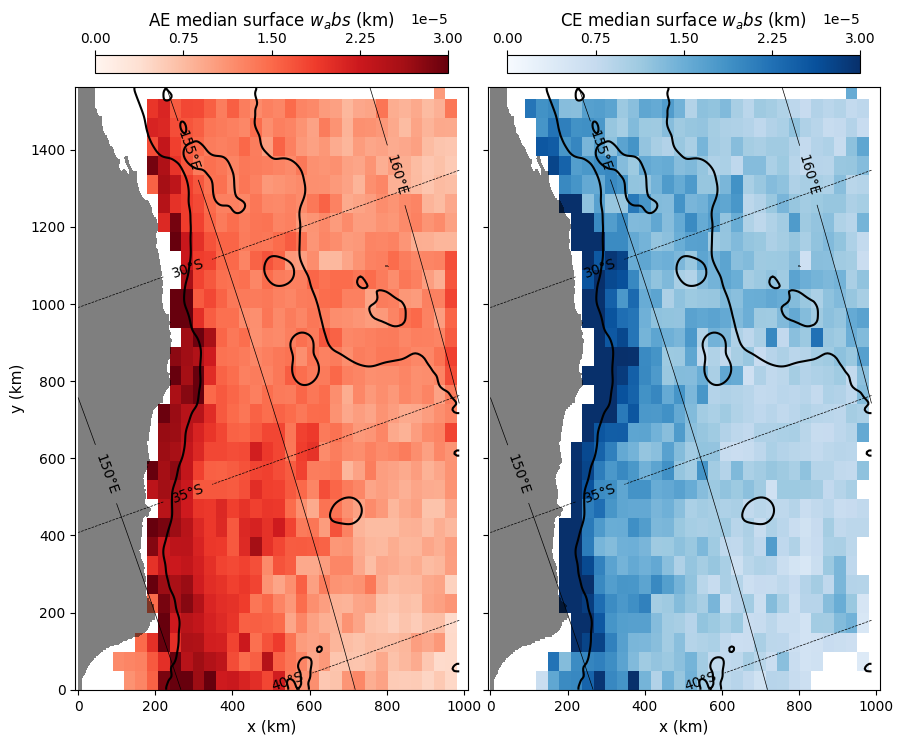

In [8]:
df_ameda['w_abs'] = df_ameda.w.abs()
fig, axs = plot_binned_median_map(df_ameda, metric='w_abs', vmin=0, vmax=3e-5)


In [9]:
df_ameda.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w', 'OW',
       'ke', 'velmax', 'rmax', 'Age', 'Date', 'fname', 'shapes1', 'calcul',
       'large1', 'split', 'split2', 'merge', 'merge2', 'shapes2',
       'interaction', 'interaction2', 'area', 'deta', 'w_abs'],
      dtype='object')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


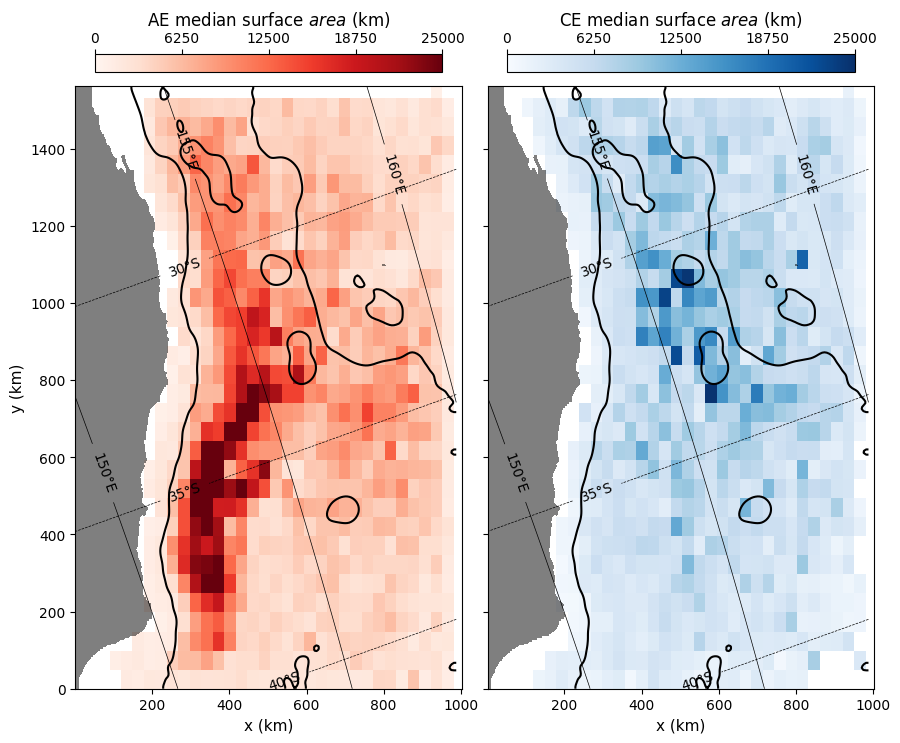

In [10]:
fig, axs = plot_binned_median_map(df_ameda, metric='area', vmin=0, vmax=25000)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


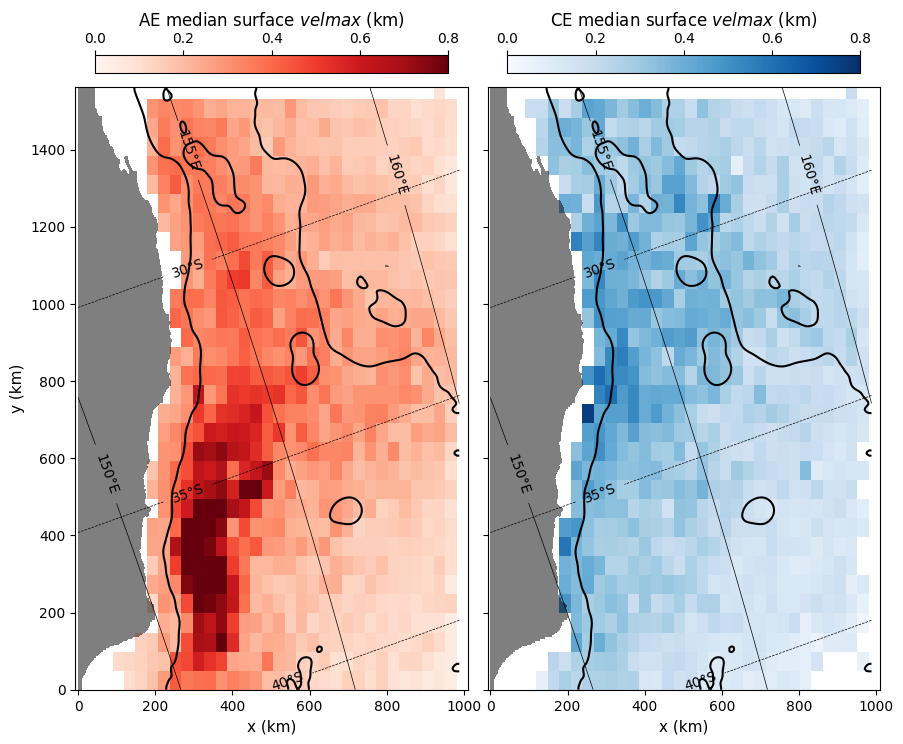

In [11]:
fig, axs = plot_binned_median_map(df_ameda, metric='velmax', vmin=0, vmax=.8)


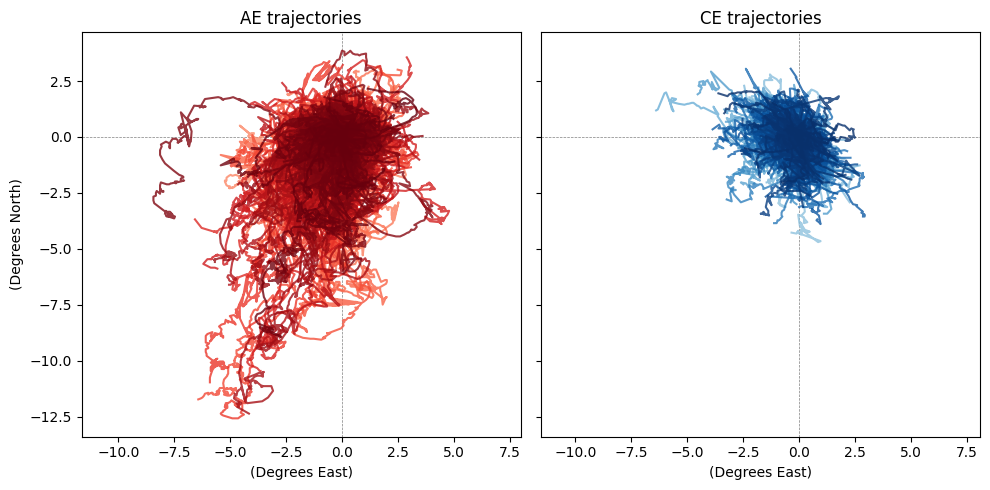

In [12]:
import matplotlib.cm as cm

fig, axs = plt.subplots(1, 2, figsize=(10,5), sharey=True)
for ax in axs:
    ax.axhline(y=0, color='k', ls='--', alpha=.5, lw=.5)
    ax.axvline(x=0, color='k', ls='--', alpha=.5, lw=.5)
# separate groups
ae = [e for e in df_ameda.Eddy.unique() if df_ameda[df_ameda.Eddy==e].iloc[0].Cyc == 'AE']
ce = [e for e in df_ameda.Eddy.unique() if df_ameda[df_ameda.Eddy==e].iloc[0].Cyc != 'AE']

# colour ranges
colors_ae = cm.Reds(np.linspace(0.4, 1, len(ae)))
colors_ce = cm.Blues(np.linspace(0.4, 1, len(ce)))

for c, eddy in zip(colors_ae, ae):
    df = df_ameda[df_ameda.Eddy==eddy]
    axs[0].plot(df.lon-df.iloc[0].lon, df.lat-df.iloc[0].lat, color=c, alpha=0.8)

for c, eddy in zip(colors_ce, ce):
    df = df_ameda[df_ameda.Eddy==eddy]
    axs[1].plot(df.lon-df.iloc[0].lon, df.lat-df.iloc[0].lat, color=c, alpha=0.8)

axs[0].axis('equal'); axs[1].axis('equal')
axs[0].set_title('AE trajectories')
axs[1].set_title('CE trajectories')
axs[0].set_xlabel('(Degrees East)'); axs[0].set_ylabel('(Degrees North)')
axs[1].set_xlabel('(Degrees East)')

plt.tight_layout()
plt.show()
